In [ ]:
import rasterio as rio
from pathlib import Path
from google.colab import drive
drive.mount('/content/drive/')
import sys
sys.path.append('/content/drive/MyDrive/IRP/scripts')
import numpy as np
import DEMDataStack as ds


Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


Load training sets

In [ ]:
DEM_PATH = '/content/drive/MyDrive/IRP/Data/Russia/Russia.tif'
LABEL_PATH = '/content/drive/MyDrive/IRP/Data/Russia/Labels_final.shp'

In [ ]:
dem = ds.DataSource.from_tiff_utm(DEM_PATH, target_res=3)
labels = ds.ShapeLabels(LABEL_PATH)
stack = ds.DataStack(dem, label_shp=labels)
stack.tile_and_export(400, '/content/drive/MyDrive/IRP/Tiles/Russia')

  320 large objects (individual tiles), 28 small → 23 clusters
Found 348 label polygons → 343 clusters → generating positive tiles
Sampling 21 negative tiles (15% of 140 positives)
Done. 140 positive, 21 negative, 203 skipped (>20% empty).


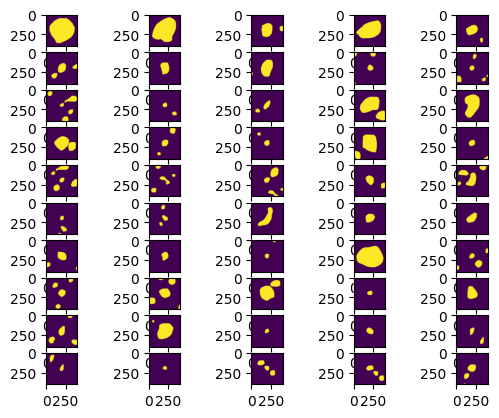

In [ ]:
import matplotlib.pyplot as plt

OUT = Path('/content/drive/MyDrive/IRP/Tiles/Russia')

paths = list(OUT.glob('*.npz'))[:50]
fig, axes = plt.subplots(10, 5)
axes = axes.flatten()

for i, p in enumerate(paths):
    tile = np.load(p)
    axes[i].imshow(tile['labels'])